In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
DATA_DIR="/content/drive/MyDrive/drug_repurposing/data"

In [3]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.0 MB/s eta 0:00:00


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, SAGEConv

from torch_geometric.transforms import RandomLinkSplit
from tqdm import tqdm
import numpy as np

In [5]:
# DATA_DIR = "data"

checkpoint=torch.load(f"{DATA_DIR}/processed/filtered_graph.pt", weights_only=False)
data=checkpoint["data"]
node_maps = checkpoint["node_maps"]
reverse_node_maps = checkpoint["reverse_node_maps"]

hidden_dim = 128

embeddings_dict = {}

for node_type in data.node_types:
    num_nodes = data[node_type].num_nodes
    emb = nn.Embedding(num_nodes, hidden_dim)
    data[node_type].x = emb.weight
    embeddings_dict[node_type] = emb

print(data)

HeteroData(
  Compound={
    num_nodes=1441,
    x=[1441, 128],
  },
  Disease={
    num_nodes=134,
    x=[134, 128],
  },
  Gene={
    num_nodes=18270,
    x=[18270, 128],
  },
  (Compound, CtD, Disease)={ edge_index=[2, 487] },
  (Gene, GiG, Gene)={ edge_index=[2, 147164] },
  (Disease, DdG, Gene)={ edge_index=[2, 7623] },
  (Compound, CbG, Gene)={ edge_index=[2, 11571] },
  (Compound, CuG, Gene)={ edge_index=[2, 18756] },
  (Disease, DaG, Gene)={ edge_index=[2, 12623] },
  (Gene, GcG, Gene)={ edge_index=[2, 61690] },
  (Gene, Gr>G, Gene)={ edge_index=[2, 265672] },
  (Compound, CdG, Gene)={ edge_index=[2, 21102] },
  (Disease, DuG, Gene)={ edge_index=[2, 7731] }
)


In [6]:
torch.manual_seed(42)

split = RandomLinkSplit(
    num_val=0.15,
    num_test=0.15,
    is_undirected=False,
    add_negative_train_samples=True,
    neg_sampling_ratio=1.0,
    edge_types=('Compound', 'CtD', 'Disease'),
)

train_data, val_data, test_data = split(data)

In [7]:
class HeteroVGAEEncoder(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.conv1 = HeteroConv({
            edge_type: SAGEConv((-1, -1), hidden_dim)
            for edge_type in data.edge_types
        }, aggr='mean')

        self.conv_mu = HeteroConv({
            edge_type: SAGEConv((-1, -1), hidden_dim)
            for edge_type in data.edge_types
        }, aggr='mean')

        self.conv_logvar = HeteroConv({
            edge_type: SAGEConv((-1, -1), hidden_dim)
            for edge_type in data.edge_types
        }, aggr='mean')

    def forward(self, x_dict, edge_index_dict):
        initial_x_dict = x_dict

        # First layer
        h_dict_1 = self.conv1(x_dict, edge_index_dict)
        h_dict_1_relu = {k: F.relu(v) for k, v in h_dict_1.items()}

        # 🔽 ADD DROPOUT HERE
        h_dict_1_relu = {k: F.dropout(v, p=0.3, training=self.training) for k, v in h_dict_1_relu.items()}

        # Merge with original features
        h_dict_merged = {
            node_type: h_dict_1_relu.get(node_type, initial_x_dict[node_type])
            for node_type in initial_x_dict.keys()
        }

        # Mu layer
        mu_dict_raw = self.conv_mu(h_dict_merged, edge_index_dict)
        mu_dict = {
            node_type: mu_dict_raw.get(node_type, h_dict_merged[node_type])
            for node_type in initial_x_dict.keys()
        }

        # Logvar layer
        logvar_dict_raw = self.conv_logvar(h_dict_merged, edge_index_dict)
        logvar_dict = {
            node_type: logvar_dict_raw.get(node_type, torch.zeros_like(h_dict_merged[node_type]))
            for node_type in initial_x_dict.keys()
        }

        return mu_dict, logvar_dict


In [8]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

In [9]:
class MLPDecoder(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(dim * 2, dim),
            nn.ReLU(),
            nn.Linear(dim, 1)
        )

    def forward(self, z_src, z_dst):
        x = torch.cat([z_src, z_dst], dim=-1)
        return self.mlp(x).squeeze()

In [10]:
device = torch.device("cpu")

# hidden_dim = 64 # Removed redundant definition

encoder = HeteroVGAEEncoder(hidden_dim).to(device)
decoder = MLPDecoder(hidden_dim).to(device)

optimizer = torch.optim.Adam(
    list(encoder.parameters()) +
    list(decoder.parameters()) +
    [p for emb in embeddings_dict.values() for p in emb.parameters()],
    lr=0.003,
    weight_decay=5e-4
)

bce_loss = nn.BCEWithLogitsLoss()

/tmp/ipykernel_2968/1130666724.py:5: UserWarning: There exist node types ({'Compound'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.conv1 = HeteroConv({
/tmp/ipykernel_2968/1130666724.py:10: UserWarning: There exist node types ({'Compound'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.conv_mu = HeteroConv({
/tmp/ipykernel_2968/1130666724.py:15: UserWarning: There exist node types ({'Compound'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.conv_logvar = HeteroConv({


In [11]:
def kl_loss(mu_dict, logvar_dict):
    kl = 0

    for key in mu_dict:
        mu = mu_dict[key]
        logvar = logvar_dict[key]

        kl += -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    return kl

In [12]:
def train():

    encoder.train()
    decoder.train()

    optimizer.zero_grad()

    mu_dict, logvar_dict = encoder(
        train_data.x_dict,
        train_data.edge_index_dict
    )

    z_dict = {
        key: reparameterize(mu_dict[key], logvar_dict[key])
        for key in mu_dict
    }

    edge_store = train_data['Compound', 'CtD', 'Disease']

    src = edge_store.edge_label_index[0]
    dst = edge_store.edge_label_index[1]

    labels = edge_store.edge_label.float()

    z_src = z_dict["Compound"][src]
    z_dst = z_dict["Disease"][dst]

    preds = decoder(z_src, z_dst)

    loss_recon = bce_loss(preds, labels)
    loss_kl = kl_loss(mu_dict, logvar_dict)

    beta = 0.001
    loss = loss_recon + beta * loss_kl

    loss.backward()
    optimizer.step()

    return loss.item()

In [13]:
from sklearn.metrics import roc_auc_score, average_precision_score

@torch.no_grad()
def evaluate(data_split):

    encoder.eval()
    decoder.eval()

    mu_dict, logvar_dict = encoder(
        data_split.x_dict,
        data_split.edge_index_dict
    )

    z_dict = mu_dict  # use mean for eval

    edge_store = data_split['Compound', 'CtD', 'Disease']

    src = edge_store.edge_label_index[0]
    dst = edge_store.edge_label_index[1]

    labels = edge_store.edge_label.cpu().numpy()

    z_src = z_dict["Compound"][src]
    z_dst = z_dict["Disease"][dst]

    preds = decoder(z_src, z_dst).cpu().numpy()

    auc = roc_auc_score(labels, preds)
    ap = average_precision_score(labels, preds)

    return auc, ap

In [14]:
num_epochs = 100

train_losses = []
val_aucs = []
val_aps = []

for epoch in range(1, num_epochs + 1):

    loss = train()
    val_auc, val_ap = evaluate(val_data)

    train_losses.append(loss)
    val_aucs.append(val_auc)
    val_aps.append(val_ap)

    print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val AUC: {val_auc:.4f} | Val AP: {val_ap:.4f}")

Epoch 001 | Loss: 0.6943 | Val AUC: 0.6836 | Val AP: 0.6925
Epoch 002 | Loss: 0.6804 | Val AUC: 0.7572 | Val AP: 0.7681
Epoch 003 | Loss: 0.6291 | Val AUC: 0.8003 | Val AP: 0.8185
Epoch 004 | Loss: 0.5963 | Val AUC: 0.8191 | Val AP: 0.8330
Epoch 005 | Loss: 0.5700 | Val AUC: 0.8193 | Val AP: 0.8306
Epoch 006 | Loss: 0.5255 | Val AUC: 0.8184 | Val AP: 0.8243
Epoch 007 | Loss: 0.4755 | Val AUC: 0.8165 | Val AP: 0.8107
Epoch 008 | Loss: 0.4198 | Val AUC: 0.8172 | Val AP: 0.8109
Epoch 009 | Loss: 0.4029 | Val AUC: 0.8221 | Val AP: 0.8038
Epoch 010 | Loss: 0.3801 | Val AUC: 0.8362 | Val AP: 0.8085
Epoch 011 | Loss: 0.3826 | Val AUC: 0.8474 | Val AP: 0.8055
Epoch 012 | Loss: 0.3719 | Val AUC: 0.8497 | Val AP: 0.8018
Epoch 013 | Loss: 0.3386 | Val AUC: 0.8489 | Val AP: 0.7937
Epoch 014 | Loss: 0.3212 | Val AUC: 0.8531 | Val AP: 0.7890
Epoch 015 | Loss: 0.3264 | Val AUC: 0.8548 | Val AP: 0.7858
Epoch 016 | Loss: 0.3198 | Val AUC: 0.8594 | Val AP: 0.7901
Epoch 017 | Loss: 0.3215 | Val AUC: 0.86

In [15]:
test_auc, test_ap = evaluate(test_data)

print("Test AUC:", test_auc)
print("Test AP:", test_ap)

Test AUC: 0.8795271157815725
Test AP: 0.8172325244126079


In [16]:
encoder.eval()

mu_dict, logvar_dict = encoder(
    data.x_dict,
    data.edge_index_dict
)

embeddings = mu_dict

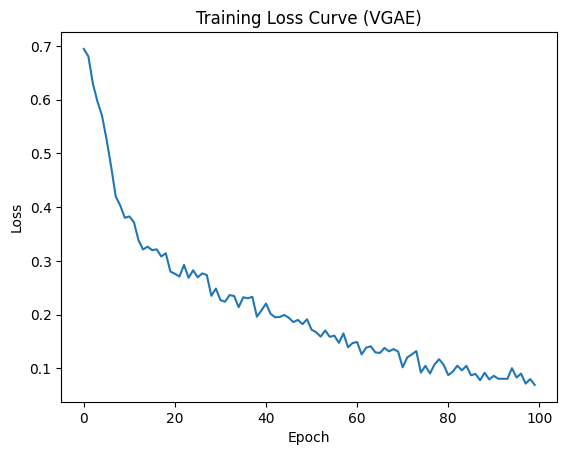

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve (VGAE)")
plt.show()

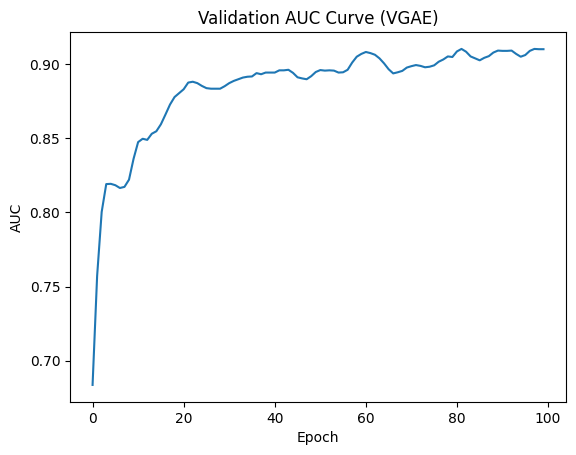

In [18]:
plt.figure()
plt.plot(val_aucs)
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Validation AUC Curve (VGAE)")
plt.show()

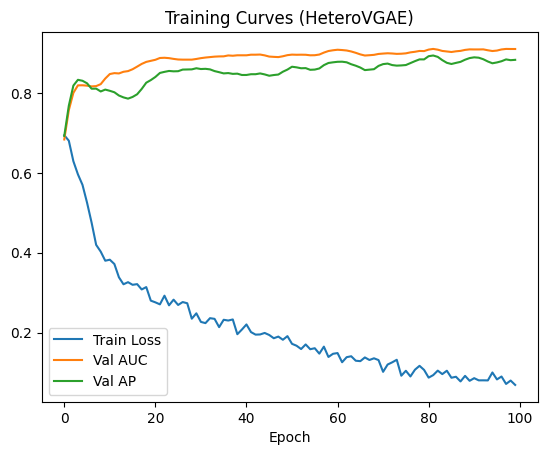

In [19]:
plt.figure()

plt.plot(train_losses, label="Train Loss")
plt.plot(val_aucs, label="Val AUC")
plt.plot(val_aps, label="Val AP")

plt.xlabel("Epoch")
plt.title("Training Curves (HeteroVGAE)")
plt.legend()

plt.show()

In [20]:
artifact = {
    "model_name": "hetero_vgae",
    "embedding_dim": hidden_dim,
    "beta": 0.001,
    "train_losses": train_losses,
    "val_aucs": val_aucs,
    "val_aps": val_aps,
    "test_auc": test_auc,
    "test_ap": test_ap,
    "embeddings": embeddings,
    "decoder_state_dict": decoder.state_dict()
}

torch.save(artifact, "/content/drive/MyDrive/drug_repurposing/models/hetero_vgae_artifact.pt")

print("Saved VGAE model artifact")

Saved VGAE model artifact


In [21]:
encoder.eval()

mu_dict, logvar_dict = encoder(
    data.x_dict,
    data.edge_index_dict
)

z_dict = mu_dict  # deterministic for visualization

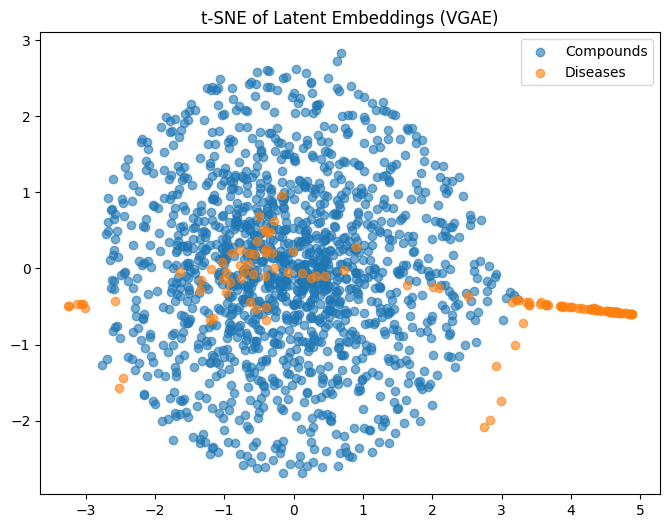

In [22]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

compound_emb = z_dict["Compound"].detach().cpu().numpy()
disease_emb = z_dict["Disease"].detach().cpu().numpy()

X = np.vstack([compound_emb, disease_emb])

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_2d = tsne.fit_transform(X)

num_compounds = len(compound_emb)

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:num_compounds, 0], X_2d[:num_compounds, 1],
            label="Compounds", alpha=0.6)
plt.scatter(X_2d[num_compounds:, 0], X_2d[num_compounds:, 1],
            label="Diseases", alpha=0.6)

plt.legend()
plt.title("t-SNE of Latent Embeddings (VGAE)")
plt.show()

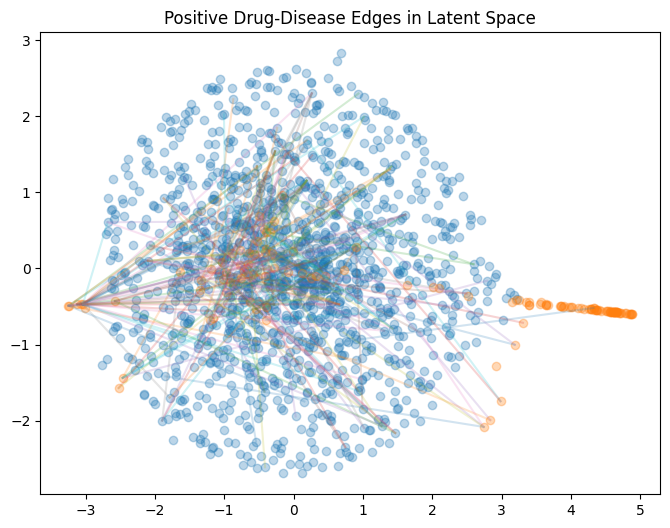

In [23]:
edge_store = data['Compound', 'CtD', 'Disease']

src = edge_store.edge_index[0][:200]   # limit for clarity
dst = edge_store.edge_index[1][:200]

plt.figure(figsize=(8,6))

# plot nodes
plt.scatter(X_2d[:num_compounds, 0], X_2d[:num_compounds, 1], alpha=0.3)
plt.scatter(X_2d[num_compounds:, 0], X_2d[num_compounds:, 1], alpha=0.3)

# draw edges
for i in range(len(src)):
    x1, y1 = X_2d[src[i]]
    x2, y2 = X_2d[num_compounds + dst[i]]
    plt.plot([x1, x2], [y1, y2], alpha=0.2)

plt.title("Positive Drug-Disease Edges in Latent Space")
plt.show()

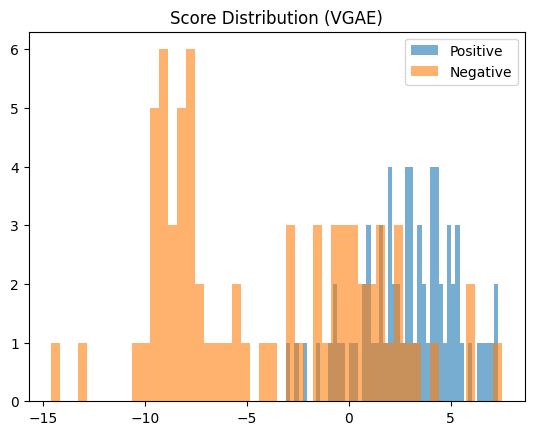

In [28]:
@torch.no_grad()
def get_scores(data_split):
    mu_dict, logvar_dict = encoder(
        data_split.x_dict,
        data_split.edge_index_dict
    )

    z_dict = mu_dict

    edge_store = data_split['Compound', 'CtD', 'Disease']
    src = edge_store.edge_label_index[0]
    dst = edge_store.edge_label_index[1]
    labels = edge_store.edge_label

    z_src = z_dict["Compound"][src]
    z_dst = z_dict["Disease"][dst]

    preds = decoder(z_src, z_dst)

    return preds.cpu().numpy(), labels.cpu().numpy()

preds, labels = get_scores(test_data)

pos_scores = preds[labels == 1]
neg_scores = preds[labels == 0]

plt.hist(pos_scores, bins=50, alpha=0.6, label="Positive")
plt.hist(neg_scores, bins=50, alpha=0.6, label="Negative")

plt.legend()
plt.title("Score Distribution (VGAE)")
plt.show()